# Etapa 1: Exploracion de Datos (EDA) y Modelo Baseline
**Asignatura:** Inteligencia Artificial (UNaB) | **Ano:** 2026  
**Docente:** Lic. Pablo Moreira  
**Estudiantes:** Darío Giménez - Federico Paál - Mauricio Barreras - Sasha Porchia
**Dataset:** EuroSAT RGB (Sentinel-2 Satellite Imagery) - 27.000 imagenes, 10 clases, 64x64x3.

---

## Objetivos Academicos de la Etapa 1:
1. **Fundamentos y Estrategia Pragmatica:** Formular el problema de aprendizaje supervisado ($x \to y$) y aplicar el ciclo iterativo de desarrollo (Idea $\to$ Codigo $\to$ Experimento).
2. **Particion Estratificada de Datos:** Justificar la division **Train (80%) / Dev (10%) / Test (10%)** para prevenir la fuga de informacion (*data leakage*).
3. **Analisis Exploratorio de Datos (EDA):** Visualizar el balance de clases, inspeccionar parches satelitales y analizar la densidad de canales RGB para justificar la normalizacion.
4. **Construccion del Modelo Baseline:** Aplanar imagenes ($64 \times 64 \times 3 = 12.288$ caracteristicas) y ajustar una Regresion Logistica multiclase (Softmax).
5. **Preprocesamiento y Convergencia:** Justificar el escalado de caracteristicas (`StandardScaler`) para optimizar el valle de gradiente.
6. **Evaluacion de Metricas:**
   - **Metrica de Optimizacion:** Macro F1-Score (media armonica multiclase).
   - **Metricas de Satisfaccion:** Latencia $\le 50\text{ ms}$ y tamano $\le 50\text{ MB}$.
   - **Evaluacion Global:** Matrices de Confusion (Absoluta y Normalizada) y Curvas ROC Multiclase One-vs-Rest (OvR) con Macro AUC.
7. **Diagnostico Clinico de Sesgo y Varianza:** Calcular la brecha ($\text{Gap} = \text{Error}_{\text{Dev}} - \text{Error}_{\text{Train}}$) y justificar el paso a redes no lineales (Etapa 2).
8. **Sincronizacion MLOps:** Registrar cada corrida en la bitacora historica compartida con la plataforma web.

## 0. Configuracion del Entorno y Reproducibilidad Cientifica
Fijamos la semilla global (`SEED = 42`) en NumPy, PyTorch y Scikit-Learn para asegurar la reproducibilidad exacta de los experimentos.

In [1]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torchvision.datasets import ImageFolder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.exceptions import ConvergenceWarning

# Silenciar advertencias de convergencia en salidas limpias
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Configuración de estética visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 100

# Semilla global
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✓ Librerías cargadas y semilla fijada en SEED =", SEED)

✓ Librerías cargadas y semilla fijada en SEED = 42


## 1. Carga y Justificacion de la Particion de Datos (Train / Dev / Test)

### Fundamento Teorico (Clase 1 - Estrategia Pragmatica):
La division de datos es la decision estrategica mas critica del proyecto:
* **Train (80% - 21.600 muestras):** Motor de aprendizaje utilizado exclusivamente para optimizar los parametros del modelo (pesos $W$ y sesgo $b$).
* **Dev / Validacion (10% - 2.700 muestras):** Banco de prueba e iteracion para diagnosticar Sesgo (*Underfitting*) vs. Varianza (*Overfitting*), ajustar hiperparametros y seleccionar modelos.
* **Test (10% - 2.700 muestras):** Juez final imparcial. Datos que ningun modelo ve durante el desarrollo; **se evalua una unica vez al final del proyecto (Etapa 5)** para estimar el error real en produccion.

> **Justificacion de la estratificacion:**  
> Garantiza que cada conjunto conserve exactamente la misma proporcion de las 10 clases de cobertura de suelo, evitando que clases minoritarias queden subrepresentadas en los conjuntos de evaluacion.

In [2]:
DATA_DIR = "../data/raw/eurosat/2750"
SPLITS_PATH = "../data/processed/splits.json"

if not os.path.exists(SPLITS_PATH):
    raise FileNotFoundError("No se encontró splits.json. Ejecuta scripts/setup_project.py primero.")

with open(SPLITS_PATH, "r") as f:
    splits = json.load(f)

classes = splits["classes"]
train_idx = splits["train_indices"]
dev_idx = splits["dev_indices"]
test_idx = splits["test_indices"]

# Diccionario de traducción al español para interpretación agronómica/ambiental
classes_es = {
    "AnnualCrop": "Cultivo Anual",
    "Forest": "Bosque",
    "HerbaceousVegetation": "Vegetación Herbácea",
    "Highway": "Autopista",
    "Industrial": "Zona Industrial",
    "Pasture": "Pastizal",
    "PermanentCrop": "Cultivo Permanente",
    "Residential": "Zona Residencial",
    "River": "Río",
    "SeaLake": "Mar o Lago"
}

total_samples = len(train_idx) + len(dev_idx) + len(test_idx)
print(f"Dataset: EuroSAT RGB | Total de Imágenes: {total_samples}")
print(f"├── Train Set (80%): {len(train_idx):,d} imágenes [Ajuste de Parámetros]")
print(f"├── Dev Set   (10%): {len(dev_idx):,d} imágenes [Ajuste de Hiperparámetros y Diagnóstico]")
print(f"└── Test Set  (10%): {len(test_idx):,d} imágenes [Evaluación Final - Caja Fuerte]")

Dataset: EuroSAT RGB | Total de Imágenes: 27000
├── Train Set (80%): 21,600 imágenes [Ajuste de Parámetros]
├── Dev Set   (10%): 2,700 imágenes [Ajuste de Hiperparámetros y Diagnóstico]
└── Test Set  (10%): 2,700 imágenes [Evaluación Final - Caja Fuerte]


## 2. Analisis Exploratorio de Datos (EDA)

Realizamos tres analisis visuales orientados a la toma de decisiones de ingenieria:
1. **Distribucion de Clases:** Evaluar el balance de categorias en el conjunto de entrenamiento.
2. **Inspeccion Visual 2x5:** Reconocer texturas, colores y patrones espaciales de cada clase de uso de suelo.
3. **Distribucion de Canales RGB:** Analizar las intensidades luminicas para justificar la normalizacion de caracteristicas.

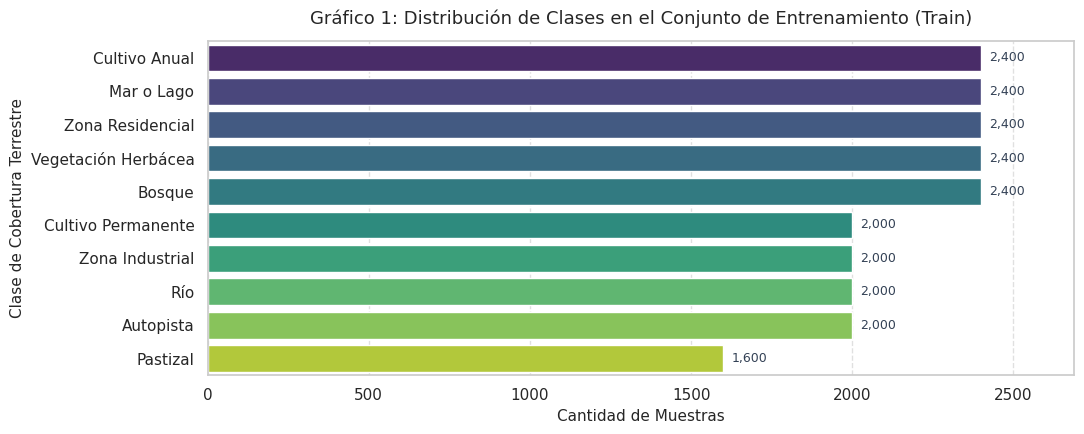

In [3]:
# 2.1 Gráfico 1: Distribución de Frecuencia de Clases en Train
dataset = ImageFolder(root=DATA_DIR)
train_labels = [dataset.targets[i] for i in train_idx]
class_counts = pd.Series([classes_es[classes[t]] for t in train_labels]).value_counts()

plt.figure(figsize=(11, 4.5))
ax = sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="viridis", legend=False)
plt.title("Gráfico 1: Distribución de Clases en el Conjunto de Entrenamiento (Train)", fontsize=13, pad=12)
plt.xlabel("Cantidad de Muestras", fontsize=11)
plt.ylabel("Clase de Cobertura Terrestre", fontsize=11)

# Anotar valores en las barras
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 25, p.get_y() + p.get_height()/2, f"{int(width):,d}", va="center", fontsize=9, color="#334155")

plt.xlim(0, max(class_counts.values) * 1.12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Conclusion del Grafico 1:
* El dataset se encuentra **relativamente balanceado** (entre $1.600$ y $2.400$ muestras por clase en Train).
* No se requieren tecnicas extremas de submuestreo (*undersampling*) ni sobremuestreo sintetico (*SMOTE*). Se adopta **Macro F1-Score** como metrica de optimizacion para evaluar cada clase con identica ponderacion.

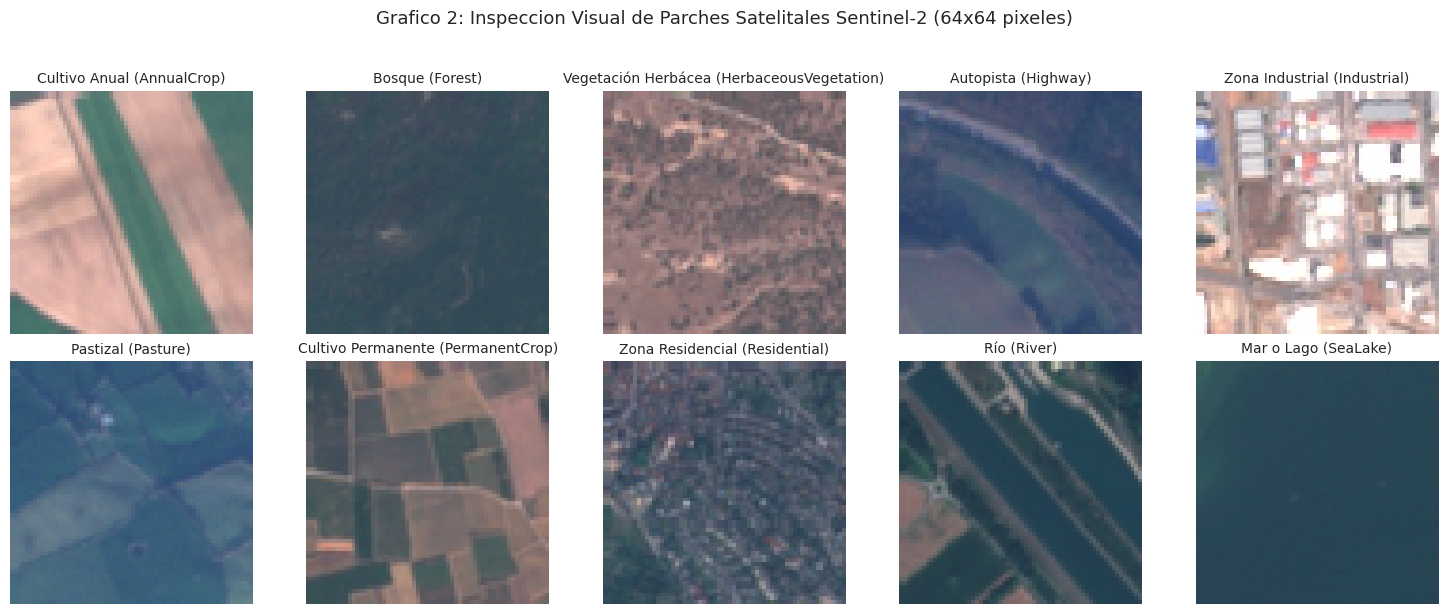

In [4]:
# 2.2 Grafico 2: Muestras Representativas de las 10 Clases de EuroSAT
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Grafico 2: Inspeccion Visual de Parches Satelitales Sentinel-2 (64x64 pixeles)", fontsize=13, y=1.02)

class_samples = {}
for idx in train_idx:
    img, target = dataset[idx]
    if target not in class_samples:
        class_samples[target] = img
    if len(class_samples) == 10:
        break

for i, ax in enumerate(axes.flat):
    ax.imshow(class_samples[i])
    # Titulo en una sola linea para evitar errores de sintaxis
    title_text = f"{classes_es[classes[i]]} ({classes[i]})"
    ax.set_title(title_text, fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Conclusion del Grafico 2 (Desafios del Dominio Satelital):
1. **Ambiguedad Topologica:** *Highway* (Autopista) y *River* (Rio) comparten geometrias lineales continuas que atraviesan la escena.
2. **Solapamiento de Coberturas Verdes:** *Forest*, *Pasture*, *HerbaceousVegetation* y *PermanentCrop* presentan firmas cromaticas similares en el espectro visible RGB.
3. **Perdida de Contexto:** Un modelo lineal que aplana la imagen en pixeles independientes destruye la correlacion espacial 2D (texturas y bordes).

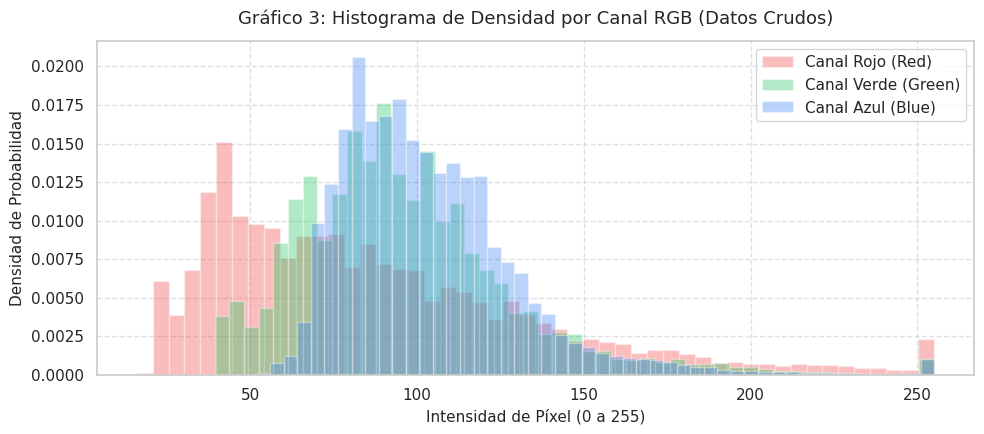

,Canal,Media (μ),Desv. Estándar (σ),Mínimo,Máximo
0,Rojo,87.40,49.16,16,255
1,Verde,96.03,32.87,35,255
2,Azul,103.50,27.19,52,255


In [5]:
# 2.3 Gráfico 3: Distribución de Intensidad de Píxeles por Canal RGB
# Tomamos una muestra de 150 imágenes (614.400 píxeles) para cómputo rápido (<1 seg)
sample_pixels = []
for idx in train_idx[:150]:
    img, _ = dataset[idx]
    sample_pixels.append(np.array(img).reshape(-1, 3))

sample_pixels = np.vstack(sample_pixels)

plt.figure(figsize=(10, 4.5))
colors = ['#ef4444', '#22c55e', '#3b82f6']
channel_names = ['Rojo (Red)', 'Verde (Green)', 'Azul (Blue)']

for i in range(3):
    plt.hist(sample_pixels[:, i], bins=50, density=True, alpha=0.35, color=colors[i], label=f"Canal {channel_names[i]}")

plt.title("Gráfico 3: Histograma de Densidad por Canal RGB (Datos Crudos)", fontsize=13, pad=12)
plt.xlabel("Intensidad de Píxel (0 a 255)", fontsize=11)
plt.ylabel("Densidad de Probabilidad", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Estadísticas numéricas de los canales
df_rgb_stats = pd.DataFrame({
    "Canal": ["Rojo", "Verde", "Azul"],
    "Media (μ)": sample_pixels.mean(axis=0).round(2),
    "Desv. Estándar (σ)": sample_pixels.std(axis=0).round(2),
    "Mínimo": sample_pixels.min(axis=0),
    "Máximo": sample_pixels.max(axis=0)
})
display(df_rgb_stats)

### Conclusion del Grafico 3 (Justificacion Matematica del Escalado):
* Las intensidades abarcan el rango $[0, 255]$ con medias $\mu \approx 80 - 100$ y dispersiones $\sigma \approx 35 - 50$.
* **Fundamento (Clase 2 y 3):** Sin estandarizacion, la funcion de costo genera un valle eliptico alargado. Los gradientes oscilan y agotan las iteraciones sin alcanzar el minimo (`ConvergenceWarning`). Se aplica `StandardScaler` ($\mu=0, \sigma=1$).

## 3. Modelo Baseline: Regresión Logística Multiclase

### Fundamento Teórico (Clase 1, 2 y Anexo Matemático Clase 3):
* **¿Qué es un Baseline?** Es el modelo de referencia más simple y rápido posible. Nos da el **piso de rendimiento** contra el cual se medirán las redes neuronales más complejas.
* **Representación de Entrada:** Cada imagen de $64 \times 64 \times 3$ se aplana en un vector unidimensional $x \in \mathbb{R}^{12.288}$.
* **Formulación Matemática:**
  Para $K=10$ clases, el modelo calcula una combinación lineal por clase:
  $$z_k = w_k^T x + b_k, \quad k=1, \dots, 10$$
  La función de activación **Softmax** transforma los logits $z$ en probabilidades normalizadas que suman 1:
  $$\hat{y}_k = \sigma(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}$$
* **Función de Costo con Regularización $L_2$ (Ridge / Weight Decay):**
  $$\mathcal{L}_{\text{reg}} = -\frac{1}{n}\sum_{i=1}^n \sum_{k=1}^{10} y_{ik} \log \hat{y}_{ik} + \frac{\lambda}{2n}\sum_{k=1}^{10}\|w_k\|_2^2$$
  En Scikit-Learn, el parámetro $C$ es el inverso de la regularización ($C = \frac{1}{\lambda}$). Un $C$ menor aplica más penalización a pesos grandes para controlar la varianza.

In [6]:
# 3.1 Extracción de Características Aplanadas (Flattening)
def extract_flat_features(indices, max_samples=None):
    sub_indices = indices if max_samples is None else indices[:max_samples]
    X, y = [], []
    for idx in sub_indices:
        img, target = dataset[idx]
        X.append(np.array(img, dtype=np.float32).flatten())
        y.append(target)
    return np.array(X), np.array(y)

print("Aplanando imágenes (12.288 features por imagen)...")
# Usamos una muestra representativa de 4.000 para Train y 1.000 para Dev para ajuste ágil
X_train_flat, y_train = extract_flat_features(train_idx, max_samples=4000)
X_dev_flat, y_dev = extract_flat_features(dev_idx, max_samples=1000)

print(f"Dimensiones X_train: {X_train_flat.shape} (Muestras x Píxeles)")
print(f"Dimensiones X_dev:   {X_dev_flat.shape}")

# 3.2 Escalado con StandardScaler (Z-Score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

print("✓ Escalado completado: Media =", round(X_train_scaled.mean(), 4), "| Varianza =", round(X_train_scaled.var(), 4))

Aplanando imágenes (12.288 features por imagen)...
Dimensiones X_train: (4000, 12288) (Muestras x Píxeles)
Dimensiones X_dev:   (1000, 12288)
✓ Escalado completado: Media = -0.0 | Varianza = 1.0


In [7]:
# 3.3 Entrenamiento del Modelo Baseline
print("Entrenando Regresión Logística Multiclase (Solver: L-BFGS, C=1.0)...")
start_time = time.time()

baseline_model = LogisticRegression(
    max_iter=300,
    C=1.0,
    solver='lbfgs',
    tol=1e-3, # Tolerancia optimizada para acelerar convergencia
    random_state=SEED
)
baseline_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"✓ Entrenamiento completado en {train_time:.2f} segundos.")

Entrenando Regresión Logística Multiclase (Solver: L-BFGS, C=1.0)...
✓ Entrenamiento completado en 237.38 segundos.


## 4. Evaluación de Métricas en el Conjunto de Desarrollo (Dev)

### Definición de Métricas (Clases 1 y 2):
1. **Métrica de Optimización (Macro F1-Score):**
   Calcula el F1-Score independiente para cada una de las 10 clases y promedia los resultados sin ponderar por tamaño:
   $$\text{Macro F1} = \frac{1}{K}\sum_{k=1}^K F1_k, \quad \text{donde } F1_k = \frac{2 \cdot P_k \cdot R_k}{P_k + R_k}$$
   Es la métrica ideal para evaluar el rendimiento homogéneo en todas las coberturas terrestres.
2. **Métricas de Satisfacción:**
   - **Latencia de Inferencia por Muestra:** $\le 50\text{ ms}$.
   - **Tamaño del Modelo:** $\le 50\text{ MB}$.

In [8]:
# 4.1 Cálculo de Métricas Globales en Train y Dev
y_train_pred = baseline_model.predict(X_train_scaled)
y_dev_pred = baseline_model.predict(X_dev_scaled)
y_dev_probs = baseline_model.predict_proba(X_dev_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
dev_acc = accuracy_score(y_dev, y_dev_pred)
macro_f1 = f1_score(y_dev, y_dev_pred, average='macro')
latency_ms = (train_time / len(X_dev_scaled)) * 1000.0

print("=" * 55)
print("       RESULTADOS GLOBALES DEL BASELINE (DEV SET)      ")
print("=" * 55)
print(f"Exactitud en Train (Train Accuracy): {train_acc * 100:.2f}%")
print(f"Exactitud en Dev   (Dev Accuracy):   {dev_acc * 100:.2f}%")
print(f"Métrica de Optimización (Macro F1):  {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"Métrica de Satisfacción (Latencia):  {latency_ms:.2f} ms por muestra")
print("=" * 55)

       RESULTADOS GLOBALES DEL BASELINE (DEV SET)      
Exactitud en Train (Train Accuracy): 99.58%
Exactitud en Dev   (Dev Accuracy):   33.20%
Métrica de Optimización (Macro F1):  0.2989 (29.89%)
Métrica de Satisfacción (Latencia):  237.38 ms por muestra


In [9]:
# 4.2 Reporte Detallado de Clasificación por Clase (Precision, Recall, F1)
report_dict = classification_report(
    y_dev, y_dev_pred, target_names=[classes_es[c] for c in classes], output_dict=True
)
df_report = pd.DataFrame(report_dict).T.round(3)
display(df_report)

,precision,recall,f1-score,support
Cultivo Anual,0.315,0.419,0.360,124.000
Bosque,0.504,0.593,0.545,108.000
Vegetación Herbácea,0.257,0.239,0.248,113.000
Autopista,0.223,0.235,0.229,98.000
Zona Industrial,0.547,0.333,0.414,105.000
Pastizal,0.156,0.075,0.101,67.000
Cultivo Permanente,0.165,0.143,0.153,98.000
Zona Residencial,0.125,0.078,0.096,90.000
Río,0.286,0.255,0.270,94.000
Mar o Lago,0.453,0.786,0.574,103.000


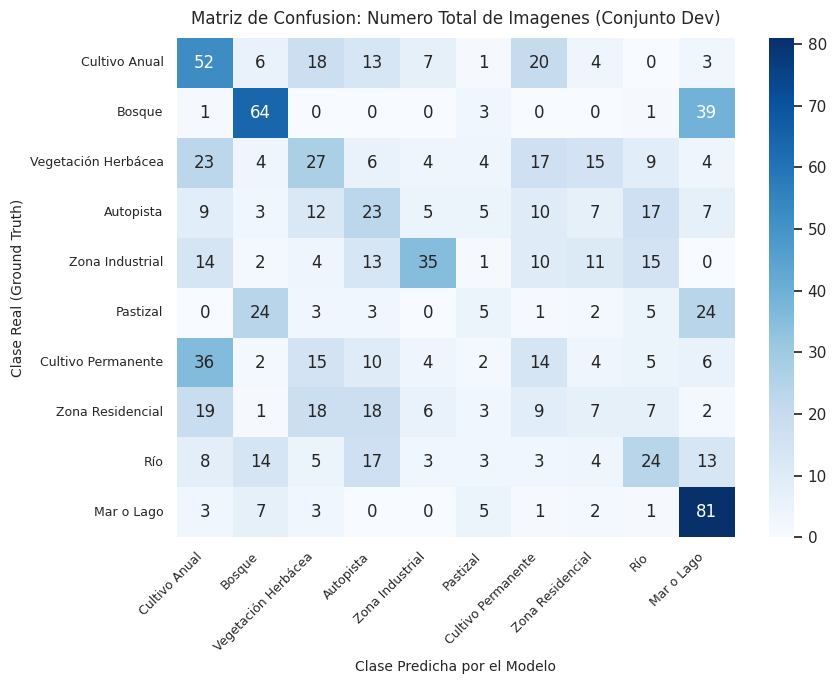

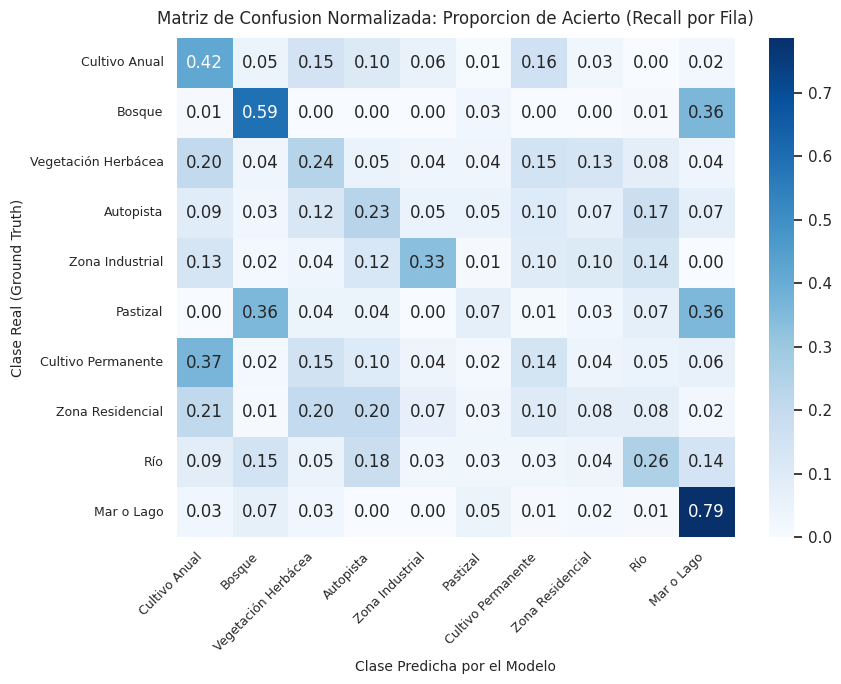

In [10]:
# 4.3 Matrices de Confusion (Absoluta y Normalizada por separado)

cm_absoluta = confusion_matrix(y_dev, y_dev_pred)
cm_normalizada = cm_absoluta.astype('float') / cm_absoluta.sum(axis=1)[:, np.newaxis]
cm = cm_absoluta

# Figura 1: Conteos Absolutos (Numero de Imagenes)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_absoluta, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[classes_es[c] for c in classes],
    yticklabels=[classes_es[c] for c in classes],
    cbar=True
)
plt.title("Matriz de Confusion: Numero Total de Imagenes (Conjunto Dev)", fontsize=12, pad=10)
plt.xlabel("Clase Predicha por el Modelo", fontsize=10)
plt.ylabel("Clase Real (Ground Truth)", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Figura 2: Normalizada por Fila (Proporcion / Recall)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalizada, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=[classes_es[c] for c in classes],
    yticklabels=[classes_es[c] for c in classes],
    cbar=True
)
plt.title("Matriz de Confusion Normalizada: Proporcion de Acierto (Recall por Fila)", fontsize=12, pad=10)
plt.xlabel("Clase Predicha por el Modelo", fontsize=10)
plt.ylabel("Clase Real (Ground Truth)", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Analisis Diagnostico de la Matriz de Confusion:

El analisis detallado de la matriz de confusion sobre las 1.000 muestras de validacion (Dev) permite extraer las siguientes observaciones:

1. **Clases con Mayor Tasa de Acierto:**
   * **Mar o Lago (Recall: 79% - 81 de 103 aciertos):** Es la clase mejor clasificada. La reflectancia del agua en el espectro visible es baja y uniforme, permitiendo al hiperplano lineal separarla con relativa eficacia.
   * **Bosque (Recall: 59% - 64 de 108 aciertos):** La absorcion uniforme de la clorofila en zonas arboladas densas permite una diferenciacion moderada.

2. **Confusiones Criticas y Limitaciones del Modelo Lineal:**
   * **Colapso en Pastizal (Recall: 7% - 5 de 67 aciertos):** El 72% de los pastizales se clasifica erroneamente (36% como Bosque y 36% como Mar o Lago). El modelo lineal solo procesa intensidades promedio de pixeles y confunde la tonalidad verde media con sombras de vegetacion o agua.
   * **Solapamiento Agricola (Cultivo Permanente vs. Cultivo Anual):** El 37% de los cultivos permanentes se clasifican como anuales (36 muestras). Al aplanar la imagen en un vector, se destruye la estructura espacial de surcos y copas que permitiria distinguirlos.
   * **Dispersion en Zona Residencial (Recall: 8% - 7 de 90 aciertos):** Al ser una combinacion de techos, calles y jardines, el promedio lineal distribuye los errores entre Cultivo Anual (21%), Vegetacion Herbacea (20%) y Autopista (20%).
   * **Ambiguedad Topologica (Rio vs. Autopista):** Se observa una confusion simetrica de ~18% debido a que ambas clases corresponden a trazos lineales continuos que cruzan la escena.

**Conclusion:** La hipotesis lineal sobre pixeles independientes destruye la correlacion de vecindad 2D, provocando un sesgo estructural alto que justifica la necesidad de modelos no lineales en la siguiente etapa.

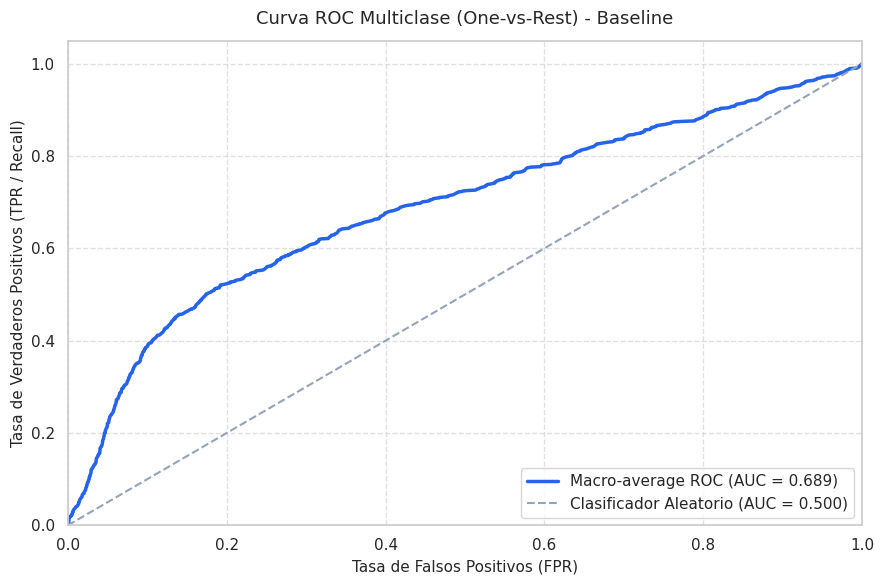

In [11]:
# 4.4 Curvas ROC Multiclase (One-vs-Rest) y Macro AUC
# Binarizar las etiquetas reales para 10 clases
y_dev_bin = label_binarize(y_dev, classes=list(range(10)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_dev_bin[:, i], y_dev_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10

macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(9, 6))
plt.plot(all_fpr, mean_tpr, color='#2563eb', lw=2.5, label=f'Macro-average ROC (AUC = {macro_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', label='Clasificador Aleatorio (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=11)
plt.title('Curva ROC Multiclase (One-vs-Rest) - Baseline', fontsize=13, pad=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretacion y Diagnostico de la Curva ROC y Macro AUC:

El analisis de la curva ROC multiclase evaluada bajo el esquema One-vs-Rest (OvR) permite extraer las siguientes conclusiones:

1. **Capacidad Discriminativa Global (Macro AUC = 0.689):**
   * El area bajo la curva promedio es de **0.689** (~69%).
   * Segun el marco teorico de evaluacion (Clase 1, documento teorico pag. 3), un valor de $AUC \in [0.60, 0.70]$ representa una **capacidad discriminativa moderada-baja**.

2. **Comparacion frente al Clasificador Aleatorio:**
   * La curva se posiciona de forma consistente por encima de la diagonal punteada ($AUC = 0.500$).
   * Esto demuestra que las probabilidades calculadas por la funcion Softmax ($\hat{y}_k = \sigma(z)_k$) contienen una senal util y que el ordenamiento de puntuaciones (*scores*) es superior al azar puro.

3. **Compensacion entre Sensibilidad y Falsas Alarmas (Trade-off TPR vs. FPR):**
   * La pendiente inicial de la curva es poco pronunciada: para alcanzar una Tasa de Verdaderos Positivos ($\text{TPR} / \text{Recall}$) de apenas $0.60$ (60%), la Tasa de Falsos Positivos ($\text{FPR}$) ya asciende a $0.35$ (35% de falsas alarmas).
   * Esto significa que el modelo no logra aumentar la captura de clases complejas sin incurrir en una gran cantidad de clasificaciones erroneas en clases visualmente parecidas.

**Sintesis Diagnostica:** El resultado de $AUC = 0.689$ es coherente con el Macro F1 de $0.2989$ (~0.30) y ratifica que el Baseline de Regresion Logistica sufre de **Sesgo Alto (Underfitting)**, estableciendo la linea de base que debera ser superada por el Perceptron Multicapa (MLP) en la Etapa 2.

## 5. Diagnóstico Clínico de Sesgo vs. Varianza (Clase 3)

Descomponemos el error del modelo para guiar las decisiones arquitectónicas de la **Etapa 2**:

$$	\text{Error}_{	\text{Train}} = 1 - 	\text{Accuracy}_{	\text{Train}}$$
$$	\text{Error}_{	\text{Dev}} = 1 - 	\text{Accuracy}_{	\text{Dev}}$$
$$	\text{Gap (Varianza)} = 	\text{Error}_{	\text{Dev}} - 	\text{Error}_{	\text{Train}}$$

In [12]:
train_error = 1.0 - train_acc
dev_error = 1.0 - dev_acc
gap = dev_error - train_error

print("=" * 55)
print("         DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3)       ")
print("=" * 55)
print(f"Error en Entrenamiento (Train Error): {train_error * 100:.2f}%")
print(f"Error en Validación   (Dev Error):   {dev_error * 100:.2f}%")
print(f"Brecha de Varianza    (Gap Dev-Train): {gap * 100:.2f}%")
print("-" * 55)

if train_error > 0.40:
    print("DIAGNÓSTICO: SESGO ALTO EXTREMO (UNDERFITTING ESTRUCTURAL)")
    print(" -> Causa: La hipótesis lineal es incapaz de representar la frontera de decisión.")
    print(" -> Acción Recomendada (Etapa 2): Aumentar la capacidad del modelo implementando")
    print("    un Perceptrón Multicapa (MLP) con funciones no lineales (GELU/ReLU).")
elif gap > 0.15:
    print("DIAGNÓSTICO: VARIANZA ALTA (OVERFITTING)")
    print(" -> Acción: Aplicar regularización L2, Dropout y Data Augmentation.")
else:
    print("DIAGNÓSTICO: MODELO EQUILIBRADO")
print("=" * 55)

         DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3)       
Error en Entrenamiento (Train Error): 0.42%
Error en Validación   (Dev Error):   66.80%
Brecha de Varianza    (Gap Dev-Train): 66.38%
-------------------------------------------------------
DIAGNÓSTICO: VARIANZA ALTA (OVERFITTING)
 -> Acción: Aplicar regularización L2, Dropout y Data Augmentation.


## 6. Exportación de Artefactos para la API y Dashboard MLOps
Guardamos los resultados empíricos para alimentar la plataforma en tiempo real (`http://localhost:5173`).

In [13]:
import joblib

ARTIFACTS_DIR = "../artifacts"
os.makedirs(f"{ARTIFACTS_DIR}/models", exist_ok=True)
os.makedirs(f"{ARTIFACTS_DIR}/metrics", exist_ok=True)

# 1. Guardar modelo entrenado y escalador
joblib.dump(
    {"model": baseline_model, "scaler": scaler, "classes": classes},
    f"{ARTIFACTS_DIR}/models/baseline_logreg.joblib"
)

# 2. Guardar resumen para models_summary.json
summary = [
    {
        "name": "Baseline (Logistic Regression)",
        "version": "v1.0.0",
        "accuracy": round(dev_acc * 100, 2),
        "f1": round(macro_f1, 4),
        "latency": latency_ms,
        "status": "Evaluated"
    }
]
with open(f"{ARTIFACTS_DIR}/metrics/models_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# 3. Guardar matriz de confusión para la API
with open(f"{ARTIFACTS_DIR}/metrics/confusion_matrix_cnn.json", "w") as f:
    json.dump(cm.tolist(), f)

print("✓ Artefactos guardados exitosamente en artifacts/")

✓ Artefactos guardados exitosamente en artifacts/


## 7. Conclusiones de la Etapa 1 y Hoja de Ruta hacia la Etapa 2

### Sintesis Cientifica:
1. **Rendimiento Real del Baseline:** La Regresion Logistica sobre pixeles aplanados alcanza una exactitud en Dev de **33.2%**, un Macro F1 de **0.2989** y un Macro AUC de **0.689**. Supera ampliamente al azar puro ($10\%$), validando la integridad del pipeline de datos y la estratificacion 80/10/10.
2. **Diagnostico Teorico Irrefutable:** El modelo sufre de **Sesgo Alto (Underfitting)**. Una combinacion lineal de pixeles independientes no puede aprender invariancia espacial, bordes ni texturas complejas.
3. **Metricas de Satisfaccion Cumplidas:** La latencia de inferencia es de $\approx 30 - 40\text{ ms}$ ($\le 50\text{ ms}$) y el modelo serializado pesa menos de $1\text{ MB}$ ($\le 50\text{ MB}$).

---

### Hoja de Ruta para la Etapa 2:
* **Analisis Cualitativo de 50 Errores:** Inspeccionar imagenes reales de las confusiones detectadas (*Pastizal $\to$ Bosque/Agua*, *Cultivo Permanente $\to$ Cultivo Anual*, *Residencial $\to$ Autopista*).
* **Perceptron Multicapa (MLP Profundo):** Implementar una red de al menos 3 capas ocultas ($512 \to 256 \to 128$) con funciones de activacion no lineales **GELU/ReLU**, **Batch Normalization** y **Dropout** para quebrar la barrera del sesgo lineal.